In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays as hd

In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [3]:
weather_data = pd.read_csv('../data/raw/Weather_YVR.csv')

In [4]:
# loading the datasets
residential_23 = pd.read_csv('../data/raw/Residential_23.csv') 
residential_24 = pd.read_csv('../data/raw/Residential_24.csv')
residential_25 = pd.read_csv('../data/raw/Residential_25.csv')
residential_27 = pd.read_csv('../data/raw/Residential_27.csv')
residential_28 = pd.read_csv('../data/raw/Residential_28.csv')

In [5]:
print(residential_23.head(5))

         date  hour  energy_kWh
0  2017-07-27     0        0.05
1  2017-07-27     1        0.07
2  2017-07-27     2        0.04
3  2017-07-27     3        0.05
4  2017-07-27     4        0.07


In [6]:
print(residential_24.head(5))

         date  hour  energy_kWh
0  2017-05-13     0        0.18
1  2017-05-13     1        0.19
2  2017-05-13     2        0.19
3  2017-05-13     3        0.18
4  2017-05-13     4        0.18


In [7]:
print(residential_25.head(5))

         date  hour  energy_kWh
0  2017-05-15     0        1.88
1  2017-05-15     1        1.14
2  2017-05-15     2        1.22
3  2017-05-15     3        1.06
4  2017-05-15     4        0.97


In [8]:
print(residential_27.head(5))

         date  hour  energy_kWh
0  2019-03-06     0        0.07
1  2019-03-06     1        0.03
2  2019-03-06     2        0.08
3  2019-03-06     3        0.07
4  2019-03-06     4        0.07


In [9]:
print(residential_28.head(5))

         date  hour  energy_kWh
0  2018-08-01     0        0.92
1  2018-08-01     1        0.91
2  2018-08-01     2        0.85
3  2018-08-01     3        0.81
4  2018-08-01     4        0.93


In [10]:
print(f"shape of 23 is: {residential_23.shape}")
print(f"shape of 24 is: {residential_24.shape}")
print(f"shape of 25 is: {residential_25.shape}")
print(f"shape of 27 is: {residential_27.shape}")
print(f"shape of 28 is: {residential_28.shape}")

shape of 23 is: (23616, 3)
shape of 24 is: (26304, 3)
shape of 25 is: (26304, 3)
shape of 27 is: (10607, 3)
shape of 28 is: (15792, 3)


In [11]:
def datetime_parsing(df, column_name = 'date'):
    df[column_name] = pd.to_datetime(df[column_name])
    df = df[df[column_name].dt.year == 2019]
    return df


In [12]:
residential_24 = datetime_parsing(residential_24)
residential_23 = datetime_parsing(residential_23)
residential_25 = datetime_parsing(residential_25)
residential_27 = datetime_parsing(residential_27)
residential_28 = datetime_parsing(residential_28)

In [13]:
residential_27.head()

,date,hour,energy_kWh
0,2019-03-06,0,0.07
1,2019-03-06,1,0.03
2,2019-03-06,2,0.08
3,2019-03-06,3,0.07
4,2019-03-06,4,0.07


In [14]:
residential_25.head()

,date,hour,energy_kWh
14305,2019-01-01,0,1.05
14306,2019-01-01,1,1.61
14307,2019-01-01,2,1.52
14308,2019-01-01,3,1.50
14309,2019-01-01,4,1.24


In [15]:
# new shape for year 2019

In [16]:
print(f"shape of 23 is: {residential_23.shape}")
print(f"shape of 24 is: {residential_24.shape}")
print(f"shape of 25 is: {residential_25.shape}")
print(f"shape of 27 is: {residential_27.shape}")
print(f"shape of 28 is: {residential_28.shape}")

shape of 23 is: (8760, 3)
shape of 24 is: (8760, 3)
shape of 25 is: (8760, 3)
shape of 27 is: (7224, 3)
shape of 28 is: (8760, 3)


In [17]:
print(residential_23.isnull().sum())
print(residential_24.isnull().sum())
print(residential_25.isnull().sum())
print(residential_27.isnull().sum())
print(residential_28.isnull().sum())

date           0
hour           0
energy_kWh    24
dtype: int64
date           0
hour           0
energy_kWh    22
dtype: int64
date           0
hour           0
energy_kWh    24
dtype: int64
date           0
hour           0
energy_kWh    22
dtype: int64
date           0
hour           0
energy_kWh    21
dtype: int64


In [18]:
residential_24 = residential_24.interpolate()
residential_23 = residential_23.interpolate()
residential_25 = residential_25.interpolate()
residential_27 = residential_27.interpolate()
residential_28 = residential_28.interpolate()

In [19]:
print(residential_23.isnull().sum())
print(residential_24.isnull().sum())
print(residential_25.isnull().sum())
print(residential_27.isnull().sum())
print(residential_28.isnull().sum())

date          0
hour          0
energy_kWh    0
dtype: int64
date          0
hour          0
energy_kWh    0
dtype: int64
date          0
hour          0
energy_kWh    0
dtype: int64
date          0
hour          0
energy_kWh    0
dtype: int64
date          0
hour          0
energy_kWh    0
dtype: int64


In [20]:
residential_23 = residential_23.rename(columns={'energy_kWh': 'energy_23'})
residential_24 = residential_24.rename(columns={'energy_kWh': 'energy_24'})
residential_25 = residential_25.rename(columns={'energy_kWh': 'energy_25'})
residential_27 = residential_27.rename(columns={'energy_kWh': 'energy_27'})
residential_28 = residential_28.rename(columns={'energy_kWh': 'energy_28'})

In [21]:
residential_23.columns

Index(['date', 'hour', 'energy_23'], dtype='object')

In [22]:
df1 = pd.merge(residential_23, residential_24, on=['date', 'hour'], how='outer')

In [23]:
df2 = pd.merge(df1, residential_25, on=['date', 'hour'], how='outer')

In [24]:
df3 = pd.merge(df2, residential_27, on=['date', 'hour'], how='outer')

In [25]:
df = pd.merge(df3, residential_28, on=['date', 'hour'], how='outer')

In [26]:
df.head()

,date,hour,energy_23,energy_24,energy_25,energy_27,energy_28
0,2019-01-01,0,1.21,0.54,1.05,NaN,2.33
1,2019-01-01,1,0.98,0.97,1.61,NaN,2.33
2,2019-01-01,2,0.97,0.21,1.52,NaN,2.03
3,2019-01-01,3,0.95,0.19,1.50,NaN,1.71
4,2019-01-01,4,1.04,0.22,1.24,NaN,1.81


In [27]:
df['avg_energy'] = df[['energy_23','energy_24','energy_25','energy_27','energy_28']].mean(axis=1)

In [28]:
df.head()

,date,hour,energy_23,energy_24,energy_25,energy_27,energy_28,avg_energy
0,2019-01-01,0,1.21,0.54,1.05,NaN,2.33,1.2825
1,2019-01-01,1,0.98,0.97,1.61,NaN,2.33,1.4725
2,2019-01-01,2,0.97,0.21,1.52,NaN,2.03,1.1825
3,2019-01-01,3,0.95,0.19,1.50,NaN,1.71,1.0875
4,2019-01-01,4,1.04,0.22,1.24,NaN,1.81,1.0775


In [29]:
df.shape

(8790, 8)

In [30]:
24*365

8760

In [31]:
duplicates = df[df.duplicated(subset=['date', 'hour'], keep=False)]
print(duplicates.shape)
print(duplicates.sort_values(['date','hour']).head(20))

(32, 8)
           date  hour  energy_23  energy_24  energy_25  energy_27  energy_28  \
7344 2019-11-03     1       0.48       0.17       0.97       2.27       1.55   
7345 2019-11-03     1       0.48       0.17       0.97       2.27       1.49   
7346 2019-11-03     1       0.48       0.17       0.97       0.13       1.55   
7347 2019-11-03     1       0.48       0.17       0.97       0.13       1.49   
7348 2019-11-03     1       0.48       0.17       0.42       2.27       1.55   
7349 2019-11-03     1       0.48       0.17       0.42       2.27       1.49   
7350 2019-11-03     1       0.48       0.17       0.42       0.13       1.55   
7351 2019-11-03     1       0.48       0.17       0.42       0.13       1.49   
7352 2019-11-03     1       0.48       0.17       0.97       2.27       1.55   
7353 2019-11-03     1       0.48       0.17       0.97       2.27       1.49   
7354 2019-11-03     1       0.48       0.17       0.97       0.13       1.55   
7355 2019-11-03     1       0.48

In [32]:
print(duplicates['date'].unique())

<DatetimeArray>
['2019-11-03 00:00:00']
Length: 1, dtype: datetime64[ns]


In [33]:
df = df.drop_duplicates(subset=['date', 'hour'], keep='first')

In [34]:
# 1. Create the missing row with NaN energy values
missing_row = pd.DataFrame({
    'date': [pd.Timestamp('2019-03-10')],
    'hour': [2],
    'energy_23': [np.nan],
    'energy_24': [np.nan],
    'energy_25': [np.nan],
    'energy_27': [np.nan],
    'energy_28': [np.nan],
    'avg_energy': [np.nan]
})



In [35]:
# concat the missing row
df = pd.concat([df, missing_row], ignore_index=True)

# sort so the new row lands in the right position
df = df.sort_values(['date', 'hour']).reset_index(drop=True)

# interpolate the NaN values
df = df.interpolate()

# verify
print(df.shape)  # should be (8760, 8)

(8760, 8)


In [36]:
df.head()

,date,hour,energy_23,energy_24,energy_25,energy_27,energy_28,avg_energy
0,2019-01-01,0,1.21,0.54,1.05,NaN,2.33,1.2825
1,2019-01-01,1,0.98,0.97,1.61,NaN,2.33,1.4725
2,2019-01-01,2,0.97,0.21,1.52,NaN,2.03,1.1825
3,2019-01-01,3,0.95,0.19,1.50,NaN,1.71,1.0875
4,2019-01-01,4,1.04,0.22,1.24,NaN,1.81,1.0775


In [37]:
weather_data = datetime_parsing(weather_data)

In [38]:
weather_data.head()

,date,hour,temperature,humidity,pressure,weather
61327,2019-01-01,1,2.0,80.0,103.12,NaN
61328,2019-01-01,2,1.6,82.0,103.08,Mostly Cloudy
61329,2019-01-01,3,1.9,79.0,103.12,NaN
61330,2019-01-01,4,1.9,82.0,103.13,NaN
61331,2019-01-01,5,2.1,80.0,103.08,Cloudy


In [39]:
weather_data.shape

(8760, 6)

In [40]:
df = pd.merge(df, weather_data, on=['date', 'hour'], how='left')

In [41]:
df.head()

,date,hour,energy_23,energy_24,energy_25,energy_27,energy_28,avg_energy,temperature,humidity,pressure,weather
0,2019-01-01,0,1.21,0.54,1.05,NaN,2.33,1.2825,NaN,NaN,NaN,NaN
1,2019-01-01,1,0.98,0.97,1.61,NaN,2.33,1.4725,2.0,80.0,103.12,NaN
2,2019-01-01,2,0.97,0.21,1.52,NaN,2.03,1.1825,1.6,82.0,103.08,Mostly Cloudy
3,2019-01-01,3,0.95,0.19,1.50,NaN,1.71,1.0875,1.9,79.0,103.12,NaN
4,2019-01-01,4,1.04,0.22,1.24,NaN,1.81,1.0775,1.9,82.0,103.13,NaN


In [42]:
df.shape

(8760, 12)

In [43]:
print(df.isnull().sum())

date              0
hour              0
energy_23         0
energy_24         0
energy_25         0
energy_27      1536
energy_28         0
avg_energy        0
temperature     365
humidity        365
pressure        365
weather        5101
dtype: int64


In [44]:
df = df.drop(columns=['weather', 'energy_23', 'energy_24', 
                       'energy_25', 'energy_27', 'energy_28'])

In [45]:
df.head()

,date,hour,avg_energy,temperature,humidity,pressure
0,2019-01-01,0,1.2825,NaN,NaN,NaN
1,2019-01-01,1,1.4725,2.0,80.0,103.12
2,2019-01-01,2,1.1825,1.6,82.0,103.08
3,2019-01-01,3,1.0875,1.9,79.0,103.12
4,2019-01-01,4,1.0775,1.9,82.0,103.13


In [46]:
df = df.interpolate()

In [47]:
df.isnull().sum()

date           0
hour           0
avg_energy     0
temperature    1
humidity       1
pressure       1
dtype: int64

In [48]:
df.head()

,date,hour,avg_energy,temperature,humidity,pressure
0,2019-01-01,0,1.2825,NaN,NaN,NaN
1,2019-01-01,1,1.4725,2.0,80.0,103.12
2,2019-01-01,2,1.1825,1.6,82.0,103.08
3,2019-01-01,3,1.0875,1.9,79.0,103.12
4,2019-01-01,4,1.0775,1.9,82.0,103.13


In [49]:
df = df.bfill()

In [50]:
df.head()

,date,hour,avg_energy,temperature,humidity,pressure
0,2019-01-01,0,1.2825,2.0,80.0,103.12
1,2019-01-01,1,1.4725,2.0,80.0,103.12
2,2019-01-01,2,1.1825,1.6,82.0,103.08
3,2019-01-01,3,1.0875,1.9,79.0,103.12
4,2019-01-01,4,1.0775,1.9,82.0,103.13


In [51]:
df['is_weekend'] = df['date'].dt.dayofweek >= 5
df['is_weekend'] = df['is_weekend'].astype(int)

In [52]:
bc_holidays = hd.Canada(prov='BC', years=2019)

In [54]:
print(df.columns.tolist())
df['is_holiday'] = df['date'].apply(lambda x: 1 if x in bc_holidays else 0)
print(df[['date', 'hour', 'is_weekend', 'is_holiday']].head(10))

['date', 'hour', 'avg_energy', 'temperature', 'humidity', 'pressure', 'is_weekend']
        date  hour  is_weekend  is_holiday
0 2019-01-01     0           0           1
1 2019-01-01     1           0           1
2 2019-01-01     2           0           1
3 2019-01-01     3           0           1
4 2019-01-01     4           0           1
5 2019-01-01     5           0           1
6 2019-01-01     6           0           1
7 2019-01-01     7           0           1
8 2019-01-01     8           0           1
9 2019-01-01     9           0           1


In [55]:
print(df.shape)
print(df.columns.tolist())
print(df.isnull().sum())
print(df.head(3))

(8760, 8)
['date', 'hour', 'avg_energy', 'temperature', 'humidity', 'pressure', 'is_weekend', 'is_holiday']
date           0
hour           0
avg_energy     0
temperature    0
humidity       0
pressure       0
is_weekend     0
is_holiday     0
dtype: int64
        date  hour  avg_energy  temperature  humidity  pressure  is_weekend  \
0 2019-01-01     0      1.2825          2.0      80.0    103.12           0   
1 2019-01-01     1      1.4725          2.0      80.0    103.12           0   
2 2019-01-01     2      1.1825          1.6      82.0    103.08           0   

   is_holiday  
0           1  
1           1  
2           1  


In [56]:
df.to_csv('../data/processed/energy_features_2019.csv', index=False)

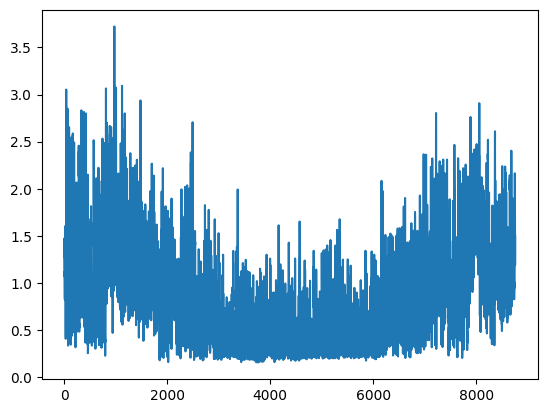

In [57]:
plt.plot(df['avg_energy'])

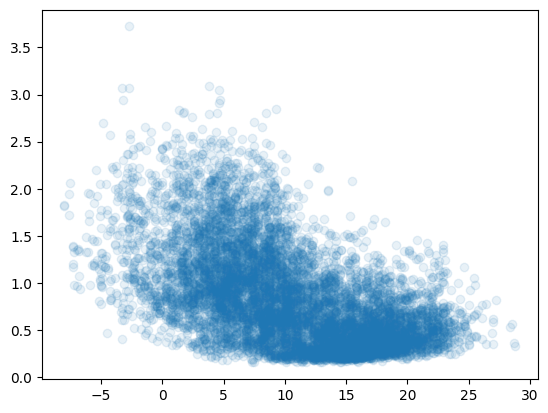

In [58]:
plt.scatter(df['temperature'], df['avg_energy'], alpha=0.1)

<Axes: xlabel='is_weekend', ylabel='avg_energy'>

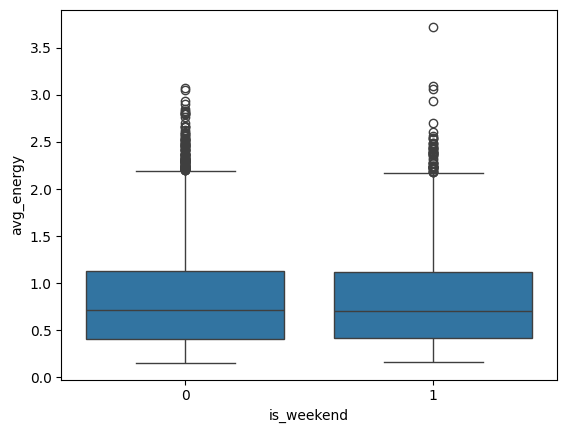

In [59]:
sns.boxplot(x='is_weekend', y='avg_energy', data=df)

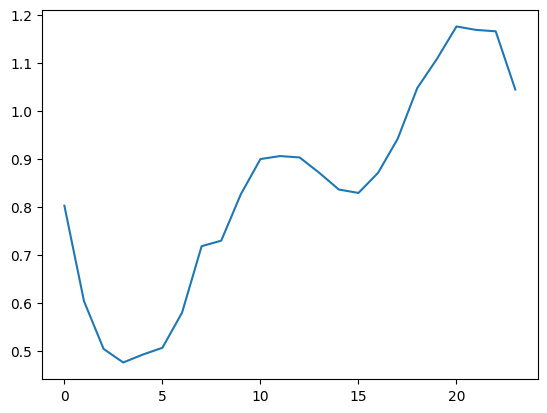

In [60]:
hourly_avg = df.groupby('hour')['avg_energy'].mean()
plt.plot(hourly_avg.index, hourly_avg.values)